In [ ]:
Name Shivam Nangare
Roll no ACT 45

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Google_Stock_Price_Train.csv to Google_Stock_Price_Train.csv


In [ ]:
# Load dataset
dataset = pd.read_csv("Google_Stock_Price_Train.csv")

In [ ]:
# View dataset
dataset.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [ ]:
# Select Open price
training_set = dataset[['Open']].values

training_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [ ]:

# Feature Scaling
scaler = MinMaxScaler(feature_range=(0, 1))

scaler

training_set_scaled = scaler.fit_transform(training_set)

training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [ ]:
# Create Time-Series Data
X_train = []
y_train = []

time_steps = 60

for i in range(time_steps, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-time_steps:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

X_train

y_train


array([0.08627874, 0.08471612, 0.07454052, ..., 0.95725128, 0.93796041,
       0.93688146])

In [ ]:
# Reshape Data for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

X_train


array([[[0.08581368],
        [0.09701243],
        [0.09433366],
        ...,
        [0.07846566],
        [0.08034452],
        [0.08497656]],

       [[0.09701243],
        [0.09433366],
        [0.09156187],
        ...,
        [0.08034452],
        [0.08497656],
        [0.08627874]],

       [[0.09433366],
        [0.09156187],
        [0.07984225],
        ...,
        [0.08497656],
        [0.08627874],
        [0.08471612]],

       ...,

       [[0.92106928],
        [0.92438053],
        [0.93048218],
        ...,
        [0.95475854],
        [0.95204256],
        [0.95163331]],

       [[0.92438053],
        [0.93048218],
        [0.9299055 ],
        ...,
        [0.95204256],
        [0.95163331],
        [0.95725128]],

       [[0.93048218],
        [0.9299055 ],
        [0.93113327],
        ...,
        [0.95163331],
        [0.95725128],
        [0.93796041]]])

In [ ]:
# Build RNN Model
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))

In [ ]:
#model.add(Dropout(0.2))

model.add(LSTM(units=50))

#model.add(Dropout(0.2))

model.add(Dense(units=1))

In [ ]:
# Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train Model
model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0393
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0021
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0018
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0016
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0016
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0015
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0015
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0014
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0014
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0016
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0013
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0014
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0015
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0012
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0014

In [ ]:
# Load Test Dataset
test_dataset = pd.read_csv("Google_Stock_Price_Test.csv")

# Real Stock Prices
real_stock_price = test_dataset[['Open']].values

real_stock_price

# Combine Train and Test Data for Prediction Input
total_data = pd.concat((dataset['Open'], test_dataset['Open']), axis=0)

total_data

inputs = total_data[len(total_data) - len(test_dataset) - time_steps:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

In [ ]:
# Prepare Test Inputs
X_test = []

for i in range(time_steps, len(inputs)):
    X_test.append(inputs[i-time_steps:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# Predict Stock Prices
predicted_stock_price = model.predict(X_test)

predicted_stock_price = scaler.inverse_transform(predicted_stock_price)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step


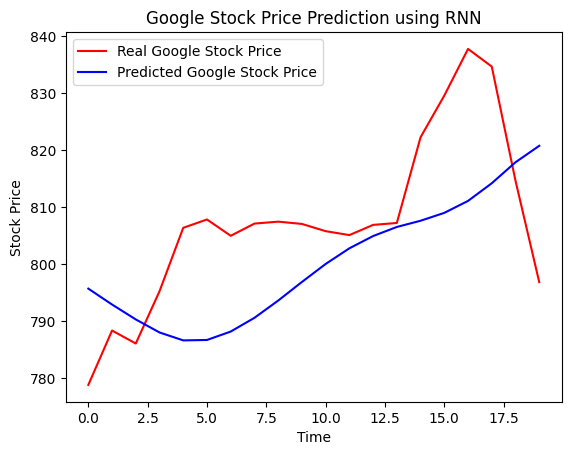

In [ ]:
# Visualization
plt.figure()
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction using RNN')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()